# Домашнее задание №3: Разметка датасета с помощью LLM

In [ ]:
# Развернем модель SmolVLM-256M с HuggingFace локально
from transformers import AutoModelForImageTextToText, AutoProcessor
import torch

MODEL_ID = "HuggingFaceTB/SmolVLM-256M-Instruct"

save_dir = "./models/smolvlm-256M"

model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    device_map = "cpu",
    torch_dtype = torch.float32,
    trust_remote_code = True
)

processor = AutoProcessor.from_pretrained(MODEL_ID)

model.save_pretrained(save_dir)
processor.save_pretrained(save_dir)

Writing model shards: 100%|██████████| 1/1 [01:04<00:00, 64.61s/it]


['./models/smolvlm-256M\\processor_config.json']

<i><b>Замечание:</b> Развернула и запустила модель локально. Протестировала ее работу на одном изображений с вопросом посчитать количество человек на картинке, как в оригинальном ноутбуке. Модели потребовалось 7 минут сгенерировать ответ. С учетом количества изображений для разметки сам процесс длился бы очень долго, поэтому перенесла модель в Google Collab для работы с GPU, но раз исходно развернула SmolVLM-256M-Instruct решила ее оставить.</i>

Дальше запуск модели в Google Collab.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from transformers import AutoModelForImageTextToText, AutoProcessor
import torch

In [9]:
import os
import json
from pathlib import Path


MODEL_DIR = Path(r"/content/drive/MyDrive/ИТМО | Магистратура/Проектирование ахритектур НС_сем.2/models/smolvlm-256M") # указываем путь до используемой модели
IMAGE_DIR = "/content/drive/MyDrive/ИТМО | Магистратура/Проектирование ахритектур НС_сем.2/data"
OUTPUT_FILE = "dataset.jsonl"

if not MODEL_DIR.is_dir():
    raise FileNotFoundError(f"Каталог модели не найден: {MODEL_DIR}")


model = AutoModelForImageTextToText.from_pretrained(
    str(MODEL_DIR),
    device_map="auto",
    torch_dtype=torch.float16,
    local_files_only=True
)

processor = AutoProcessor.from_pretrained(
    str(MODEL_DIR),
    local_files_only=True,
)

print("Модель загружена из:", MODEL_DIR.resolve())

Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

Модель загружена из: /content/drive/MyDrive/ИТМО | Магистратура/Проектирование ахритектур НС_сем.2/models/smolvlm-256M


Код ниже немного переделан, чтобы не требовал использование `process_vision_info` из библиотеки `qwen_vl_utils`.

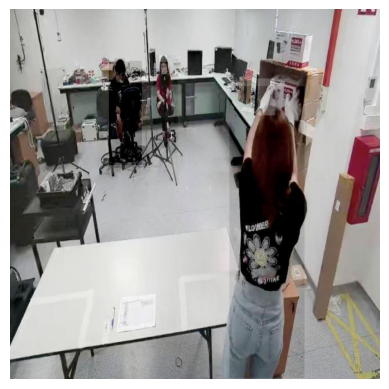

Промпт: How many people are there in the photo? Describe them in great detail
Ответ:  There are three people in the photo.


In [4]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import torch

TEST_IMAGE = Path("/content/drive/MyDrive/ИТМО | Магистратура/Проектирование ахритектур НС_сем.2/test.jpg")

if not TEST_IMAGE.is_file():
    raise FileNotFoundError(f"Картинка не найдена: {TEST_IMAGE.resolve()}")

image_cv = cv2.imread(str(TEST_IMAGE))[:, :, ::-1]
plt.imshow(image_cv)
plt.axis('off')
plt.show()

image_pil = Image.open(TEST_IMAGE)

TEST_PROMPT = "How many people are there in the photo? Describe them in great detail"

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": TEST_PROMPT},
        ],
    }
]

text = processor.apply_chat_template(
    messages,
    tokenize = False,
    add_generation_prompt = True,
)

inputs = processor(
    text = [text],
    images = [image_pil],
    return_tensors = "pt"
)

inputs = inputs.to(model.device)

generated_ids = model.generate(
    **inputs,
    max_new_tokens = 128,
    do_sample = False,
)

generated_ids_trimmed = [
    out_ids[len(in_ids) :]
    for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]

answer = processor.batch_decode(
    generated_ids_trimmed,
    skip_special_tokens = True,
    clean_up_tokenization_spaces = False,
)[0]

print("Промпт:", TEST_PROMPT)
print("Ответ:", answer)


In [23]:
PROMPT = """
Describe the image in one sentence.

Include only:
- the main objects
- the primary action
- the main scene

Do not include minor details, colors, or attributes.
Return exactly ONE SENTENCE, no matter what.
Do not repeat or summarize; just output one sentence.
"""

all_items = []

files = sorted(os.listdir(IMAGE_DIR))

for file_name in files:

    if not file_name.lower().endswith(
        (".jpg", ".jpeg", ".png", ".webp")
    ):
        continue

    image_path = os.path.join(IMAGE_DIR, file_name)

    print(f"Processing: {file_name}")

    image_pil = Image.open(image_path)

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": PROMPT}
            ]
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = processor(
        text=[text],
        images=[image_pil],
        padding=True,
        return_tensors="pt"
    )

    inputs = inputs.to(model.device)

    generated_ids = model.generate(
        **inputs,
        max_new_tokens=60,
        do_sample=False
    )

    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(
            inputs.input_ids,
            generated_ids
        )
    ]

    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    item = {
        "image": image_path,
        "text": output_text
    }

    all_items.append(item)

    print(output_text)


Processing: -01-16-2-3-2-5-15_jpg.rf.3a82c0e7cb6b006df4c9fc87d9b55368.jpg
 The room is full of boxes.
Processing: -01-16-2-3-2-5-15_jpg.rf.705a29a51fa44f15dbe29adcaf09d2e0.jpg
 The room is full of boxes.
Processing: -01-16-2-3-2-5-20_jpg.rf.ff89baa4ddffc68390a744645a32236d.jpg
 The image shows a room with several tables and several boxes.
Processing: -01-16-2-4-2-1-28_jpg.rf.ebeb8cf9d541d5af713ac4414162e366.jpg
 The room is full of boxes.
Processing: -01-16-2-4-2-1-43_jpg.rf.ff99aa037d9bfedd3db50d5fb33aec86.jpg
 The main objects in the room are computers.
Processing: -01-16-2-4-2-2-25_jpg.rf.1ba567b4c64d53342ed4dc1200fcfa2d.jpg
 The room is in a business.
Processing: -01-16-2-4-2-2-33_jpg.rf.e314997ea7789b9c5f6124c04783d3a7.jpg
 The image in the picture shows a woman in front of a room with cubicles.
Processing: -01-16-2-4-2-2-39_jpg.rf.ac94511f8a64fa635875cf11c54c79cb.jpg
 The room is packed.
Processing: -01-16-2-4-2-2-42_jpg.rf.965ebc2c5db9acbde62cd8a098f88821.jpg
 The person is look

Можно заметить, что для осного избражения модель вернула описание на китайском. Также для одного изображения полученное описание слишком длинное. 

In [ ]:
# На паре примеров модель не вернула то, что требовалось, поэтому перезапустим ее еще раз и скорректируем промпт
PROMPT = """
Describe the image in english.
Include only:
- the main objects
- the primary action
- the main scene
Do not include minor details, colors, or attributes.
Return exactly ONE SENTENCE FULLY IN ENGLISH, no matter what.
Do not repeat or summarize; just output one sentence.
"""

all_items = []

files = sorted(os.listdir(IMAGE_DIR))

for file_name in files:

    if not file_name.lower().endswith(
        (".jpg", ".jpeg", ".png", ".webp")
    ):
        continue

    image_path = os.path.join(IMAGE_DIR, file_name)

    print(f"Processing: {file_name}")

    image_pil = Image.open(image_path)

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": PROMPT}
            ]
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = processor(
        text=[text],
        images=[image_pil],
        padding=True,
        return_tensors="pt"
    )

    inputs = inputs.to(model.device)

    generated_ids = model.generate(
        **inputs,
        max_new_tokens = 64,
        do_sample=False
    )

    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(
            inputs.input_ids,
            generated_ids
        )
    ]

    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    item = {
        "image": image_path,
        "text": output_text
    }

    all_items.append(item)

    print(output_text)


Processing: -01-16-2-3-2-5-15_jpg.rf.3a82c0e7cb6b006df4c9fc87d9b55368.jpg
 The room is full of boxes.
Processing: -01-16-2-3-2-5-15_jpg.rf.705a29a51fa44f15dbe29adcaf09d2e0.jpg
 The room is full of boxes.
Processing: -01-16-2-3-2-5-20_jpg.rf.ff89baa4ddffc68390a744645a32236d.jpg
 The woman is putting a box in her carton.
Processing: -01-16-2-4-2-1-28_jpg.rf.ebeb8cf9d541d5af713ac4414162e366.jpg
 A woman looks at boxes in a room.
Processing: -01-16-2-4-2-1-43_jpg.rf.ff99aa037d9bfedd3db50d5fb33aec86.jpg
 The folder is empty.
Processing: -01-16-2-4-2-2-25_jpg.rf.1ba567b4c64d53342ed4dc1200fcfa2d.jpg
 The people are in a room.
Processing: -01-16-2-4-2-2-33_jpg.rf.e314997ea7789b9c5f6124c04783d3a7.jpg
 The place has a lot of cubicles.
Processing: -01-16-2-4-2-2-39_jpg.rf.ac94511f8a64fa635875cf11c54c79cb.jpg
 The woman is carrying boxes.
Processing: -01-16-2-4-2-2-42_jpg.rf.965ebc2c5db9acbde62cd8a098f88821.jpg
 The person is looking in the direction of the camera.
Processing: -01-16-2-4-2-3-49_jp

Наверное не идеально, но хотя бы больше нет ктайского описания &#128522;

In [33]:
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    for item in all_items:
        f.write(
            json.dumps(item, ensure_ascii=False) + "\n"
        )

print(f"Saved to {OUTPUT_FILE}")

Saved to dataset.jsonl


Файл с финальными аннотациями `dataset.jsonl` выложен в общей папке с заданиями на GitHub.